---

# <span style="color:#1F4E79;">25340 Digital Ocean</span>
### <span style="color:#2E86AB;">Sea Surface Temperature Anomalies and Atmospheric Drivers of the North Atlantic Marine Heatwaves</span>

---

## <span style="color:#1F4E79;">Table of Contents</span>
- [Part 1: Data Collection](#Part-1:-Data-Collection)
- [Part 2: Split Beam](#Part-2:-Split-Beam)

---

In [1]:
# Import necessary libraries
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import dates as mdates
import copernicusmarine
import warnings
from matplotlib.patches import Patch
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output

c:\Users\natal\repos\OceanCourses\.ocean\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
# Part 1: Data Collection

The data will be collected from 2 periods (5 months) for 2 Marine Heatwave events:
1. December 2015 - April 2016
2. May 2023 - September 2023

If the date is not downloaded on your computer please run the DataDownload.ipynb file to get the neccessary files.

---
# Part 2: Data Investigation

In [2]:
# Load the dataset
ds_2016 = xr.open_dataset("Data/atl_sst_mhw_2016.nc")
ds_2023 = xr.open_dataset("Data/atl_sst_mhw_2023.nc")

# Merge the datasets along the time dimension
ds = xr.concat([ds_2016, ds_2023], dim='time')

In [14]:
# Variable name mapping with units for clearer graph titles/labels
var_names = {
    'analysed_sst': 'Sea Surface Temperature (°C)',
}

# Convert temperature from Kelvin to degree Celsius when needed
analysed_sst_mean = float(ds['analysed_sst'].mean(skipna=True).values)
if analysed_sst_mean > 100.0:
    ds['analysed_sst'] = ds['analysed_sst'] - 273.15
    ds['analysed_sst'].attrs['units'] = 'degC'

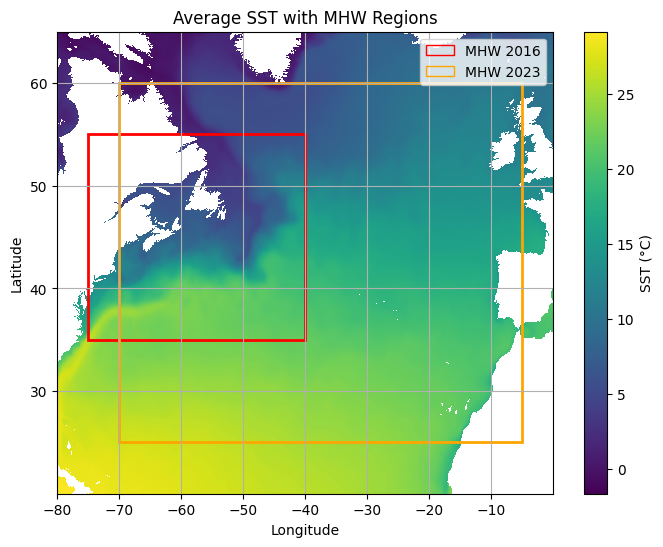

In [15]:
MHW_2016 = {        
    "minimum_longitude": -75.0,
    "maximum_longitude": -40.0,
    "minimum_latitude": 35.0,
    "maximum_latitude": 55.0,}

MHW_2023 = {
    "minimum_longitude": -70.0,
    "maximum_longitude": -5.0,
    "minimum_latitude": 25.0,
    "maximum_latitude": 60.0,
}

# Plot on the map the region of the 2016 MHW
plt.figure(figsize=(8, 6))  
plt.pcolormesh(ds.longitude, ds.latitude, ds.analysed_sst.mean(dim="time"), shading='auto', cmap='viridis')
plt.colorbar(label='SST (°C)')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Average SST with MHW Regions")
plt.grid()

# Add rectangles for MHW regions
plt.gca().add_patch(plt.Rectangle((MHW_2016["minimum_longitude"], MHW_2016["minimum_latitude"]),
                                  MHW_2016["maximum_longitude"] - MHW_2016["minimum_longitude"],
                                  MHW_2016["maximum_latitude"] - MHW_2016["minimum_latitude"],
                                  edgecolor='red', facecolor='none', lw=2, label='MHW 2016'))

plt.gca().add_patch(plt.Rectangle((MHW_2023["minimum_longitude"], MHW_2023["minimum_latitude"]),
                                  MHW_2023["maximum_longitude"] - MHW_2023["minimum_longitude"],
                                  MHW_2023["maximum_latitude"] - MHW_2023["minimum_latitude"],
                                  edgecolor='orange', facecolor='none', lw=2, label='MHW 2023'))

plt.legend(handles=[Patch(edgecolor='red', facecolor='none', label='MHW 2016'),
                    Patch(edgecolor='orange', facecolor='none', label='MHW 2023')])

plt.savefig("Figures/MHW_Regions_Map.png", dpi=300)
plt.show()